<a href="https://colab.research.google.com/github/somnath3112/DRL-fun-da/blob/somb/Saving_loading_dqn_%2B_Episode_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable Baselines3 - Setup (Training, Saving and Loading are commented out)

Github Repo: [https://github.com/DLR-RM/stable-baselines3](https://github.com/DLR-RM/stable-baselines3)


[RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) is a training framework for Reinforcement Learning (RL), using Stable Baselines3.

It provides scripts for training, evaluating agents, tuning hyperparameters, plotting results and recording videos.

Documentation is available online: [https://stable-baselines3.readthedocs.io/](https://stable-baselines3.readthedocs.io/)



## Install Dependencies and Stable Baselines Using Pip


```
pip install stable-baselines3[extra]
```

In [1]:
# for autoformatting
# %load_ext jupyter_black

In [2]:
!apt-get update && apt-get install swig cmake
!pip install box2d-py
!pip install gymnasium[box2d]
!pip install "stable-baselines3[extra]>=2.0.0a4"

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,543 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,154 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:13 https://ppa.launchpadcontent.net/graphics

## Import policy, RL agent, ...

In [3]:
import gymnasium as gym
import numpy as np

from stable_baselines3 import DQN

## Create the Gym env and instantiate the agent

For this example, we will use Lunar Lander environment.

"Landing outside landing pad is possible. Fuel is infinite, so an agent can learn to fly and then land on its first attempt. Four discrete actions available: do nothing, fire left orientation engine, fire main engine, fire right orientation engine. "

Lunar Lander environment: [https://gymnasium.farama.org/environments/box2d/lunar_lander/](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![Lunar Lander](https://cdn-images-1.medium.com/max/960/1*f4VZPKOI0PYNWiwt0la0Rg.gif)


We chose the MlpPolicy because input of Lunar Lander is a feature vector, not images.

The type of action to use (discrete/continuous) will be automatically deduced from the environment action space



In [4]:
model = DQN(
    "MlpPolicy",
    "LunarLander-v3",
    verbose=1,
    exploration_final_eps=0.1,
    target_update_interval=250,
)

Using cuda device
Creating environment from the given name 'LunarLander-v3'


/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


We load a helper function to evaluate the agent:

In [5]:
from stable_baselines3.common.evaluation import evaluate_policy

Let's evaluate the un-trained agent, this should be a random agent.

In [6]:
# Separate env for evaluation
eval_env = gym.make("LunarLander-v3")

# Random Agent, before training
mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=10,
    deterministic=True,
)

print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


mean_reward=-132.48 +/- 30.772693402332493


## Train the agent and save it

Warning: this may take a while

In [7]:
# # Train the agent
# model.learn(total_timesteps=int(1e5))
# # Save the agent
# model.save("dqn_lunar")
# del model  # delete trained model to demonstrate loading

## Load the trained agent

In [8]:
# model = DQN.load("dqn_lunar")

In [9]:
# # Evaluate the trained agent
# mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

# print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

# Fun with Lunar Lander

## Imports

In [10]:
# %pip install imageio[ffmpeg]

In [11]:
import numpy as np
import imageio

In [12]:
from PIL import Image as im

In [13]:
#@title The environment
new_env = gym.make("LunarLander-v3", render_mode='rgb_array')

## Episode generation

In [14]:
#@title Random episode

N = 30
current_rewards = 0.
current_lengths = 0.

# List to store frames
frames = []

obs, info = new_env.reset()

for i in range(N):
  action = int(np.random.choice(4,1)[0])
  print(f"The action is: {action}, the type is {type(action)}")
  obs, reward, done, truncated, info = new_env.step(action)

  current_rewards += reward
  current_lengths += 1
  # Capture the frame
  frames.append(new_env.render())

  if done:
      break  # Stop if episode ends

The action is: 2, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 1, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 1, the type is <class 'int'>
The action is: 1, the type is <class 'int'>
The action is: 1, the type is <c

In [28]:
#@title Let's generate some episodes

def generate_episode(agent = lambda obs: int(np.random.choice(4,1)[0]), N_episodes = 10, N_length_of_each_episode = 300):

  obs, info = new_env.reset()

  list_of_episodes = []

  for i in range(N_episodes):
    # Generate an episode
    current_episode = []
    for j in range(N_length_of_each_episode):
      action = agent(obs) # <-- to be changed :: prediction from agent with epsion greedy
      nxt_obs, reward, done, truncated, info = new_env.step(action)

      # Save an instant (SARS') to current episode
      instant = (obs, action, reward, nxt_obs) # drama
      current_episode.append(instant)

      if done:
        break

    # Save an episode in the list_of_episodes
    list_of_episodes.append(current_episode)


In [29]:
generate_episode()
print(f"Total number of episodes: {len(list_of_episodes)}")
print(f"Total instances/dramas in episode 1: {len(list_of_episodes[0])}")
print(f"Data of first instant/drama in episode 1:\n \t {list_of_episodes[0][0]}")

Total number of episodes: 10
Total instances/dramas in episode 1: 108
Data of first instant/drama in episode 1:
 	 (array([ 0.00581589,  1.4186312 ,  0.5890681 ,  0.34270394, -0.00673233,
       -0.13343264,  0.        ,  0.        ], dtype=float32), 3, np.float64(-1.1402546614775406), array([ 0.01171169,  1.4257537 ,  0.59828943,  0.31649202, -0.01533611,
       -0.17209016,  0.        ,  0.        ], dtype=float32))


## Observe results

In [15]:
#@title Save as a video file

video_filename = "lunar_lander.mp4"
imageio.mimsave(video_filename, frames, fps=30)

print(f"Video saved as {video_filename}")
print('Download the video and run, see below')

Video saved as lunar_lander.mp4
Download the video and run, see below


In [16]:
#@title Play the saved video

from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = "/content/" + video_filename

# Show video
mp4 = open(save_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)


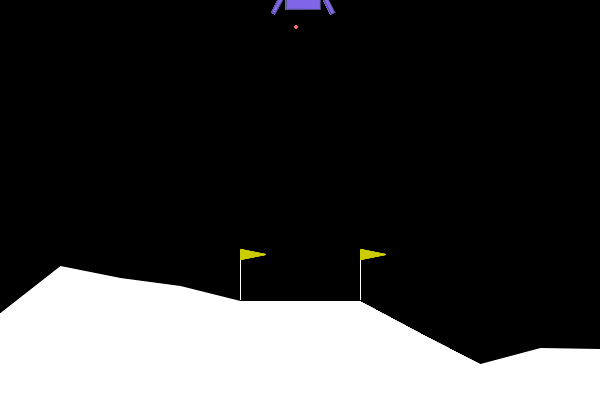
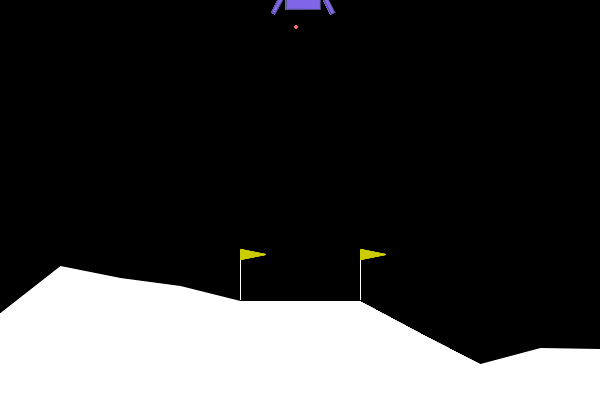

In [17]:
#@title Create gif

# Specify the output GIF file name
output_gif = "lunar_lander_results.gif"

# Write the images to a GIF file
imageio.mimsave(output_gif, frames, format='GIF') #, duration=0.5)  # Adjust duration as needed

# Show video
gif_img = open(output_gif,'rb').read()
data_url = "data:image/gif;base64," + b64encode(gif_img).decode()
# HTML(f'<img src="{data_url}" />')
HTML(f"""
<img src="{data_url}" id="gif" />
<script>
  var gif = document.getElementById("gif");
  gif.onload = function() {{
    setInterval(() => {{
      gif.src = "{data_url}"; // Reset GIF
    }}, 5000); // Adjust time based on GIF duration
  }};
</script>
""")

#### Download the video and run (expand this)

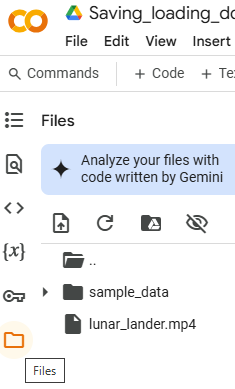

### More

In [18]:
# Close environment
new_env.close()

# new_env.render("human")

# Episode generation

# Ends